In [1]:
# Install required packages (run this cell first if packages are missing)
import sys
import subprocess

def install_package(package):
    """Install a package using pip"""
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# List of required packages
required_packages = [
    "pandas",
    "numpy", 
    "matplotlib",
    "seaborn",
    "librosa",
    "soundfile",
    "scikit-learn",
    "scipy",
    "tqdm"
]

# Install missing packages
missing_packages = []
for package in required_packages:
    try:
        __import__(package)
    except ImportError:
        missing_packages.append(package)

if missing_packages:
    print(f"Installing missing packages: {', '.join(missing_packages)}")
    for package in missing_packages:
        try:
            install_package(package)
            print(f"✓ Installed {package}")
        except Exception as e:
            print(f"✗ Failed to install {package}: {e}")
    print("\n✓ Package installation complete! Please restart the kernel and run all cells.")
else:
    print("✓ All required packages are already installed!")


Installing missing packages: scikit-learn
✓ Installed scikit-learn

✓ Package installation complete! Please restart the kernel and run all cells.


# Exploratory Data Analysis: CREMA-D Dataset

This notebook performs exploratory data analysis on the CREMA-D dataset to understand:
- Dataset structure and statistics
- Emotion distribution
- Audio characteristics
- Transcription quality
- Data splits analysis


In [2]:
# Import libraries
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


In [3]:
# Load data
import config

metadata_path = config.PROCESSED_DATA_DIR / "metadata.csv"
df = pd.read_csv(metadata_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()


Dataset shape: (7442, 17)

Columns: ['filename', 'actor_id', 'sentence', 'emotion_code', 'emotion', 'intensity_code', 'intensity', 'filepath', 'duration_x', 'original_path', 'duration_y', 'is_valid', 'processed_filepath', 'transcription', 'transcription_success', 'transcription_language', 'transcription_no_speech_prob']


,filename,actor_id,sentence,emotion_code,emotion,intensity_code,intensity,filepath,duration_x,original_path,duration_y,is_valid,processed_filepath,transcription,transcription_success,transcription_language,transcription_no_speech_prob
0,1022_ITS_ANG_XX.wav,1022,ITS,ANG,anger,XX,unspecified,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,2.435750,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,2.435750,True,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,Think I've seen this before,True,en,0.0
1,1037_ITS_ANG_XX.wav,1037,ITS,ANG,anger,XX,unspecified,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,3.003000,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,3.003000,True,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,NaN,NaN,NaN,NaN
2,1060_ITS_NEU_XX.wav,1060,ITS,NEU,neutral,XX,unspecified,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,2.402375,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,2.402375,True,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,I think I've seen this before.,True,en,0.0
3,1075_ITS_NEU_XX.wav,1075,ITS,NEU,neutral,XX,unspecified,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,2.435750,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,2.435750,True,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,I think I've seen this before.,True,en,0.0
4,1073_IOM_DIS_XX.wav,1073,IOM,DIS,disgust,XX,unspecified,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,2.869562,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,2.869562,True,/Users/pro2019/Desktop/Speech-to-Text-Sentimen...,I'm on my way to the meeting.,True,en,0.0


## 1. Dataset Overview


In [4]:
# Basic statistics
print("=" * 60)
print("Dataset Overview")
print("=" * 60)
print(f"Total files: {len(df)}")
print(f"Unique actors: {df['actor_id'].nunique()}")
print(f"Unique sentences: {df['sentence'].nunique()}")
print(f"Unique emotions: {df['emotion'].nunique()}")
print(f"\nEmotions: {sorted(df['emotion'].unique())}")
print(f"\nIntensities: {sorted(df['intensity'].unique())}")


Dataset Overview
Total files: 7442
Unique actors: 91
Unique sentences: 12
Unique emotions: 6

Emotions: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad']

Intensities: ['high', 'low', 'medium', 'unspecified', 'x']


## 2. Emotion Distribution


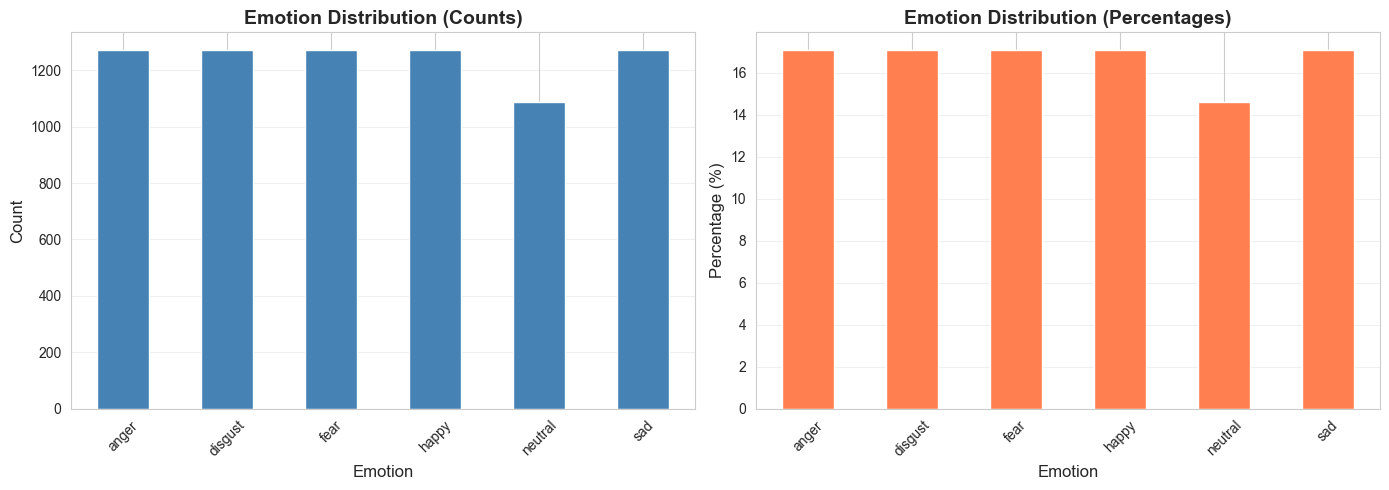


Emotion Distribution:
  anger       : 1271 files (17.08%)
  disgust     : 1271 files (17.08%)
  fear        : 1271 files (17.08%)
  happy       : 1271 files (17.08%)
  neutral     : 1087 files (14.61%)
  sad         : 1271 files (17.08%)


In [5]:
# Emotion distribution
emotion_counts = df['emotion'].value_counts().sort_index()
emotion_percentages = (emotion_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
emotion_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Emotion Distribution (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Emotion', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Percentage plot
emotion_percentages.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Emotion Distribution (Percentages)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Emotion', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\nEmotion Distribution:")
for emotion, count in emotion_counts.items():
    pct = emotion_percentages[emotion]
    print(f"  {emotion:12s}: {count:4d} files ({pct:5.2f}%)")


## 3. Transcription Analysis (if available)


In [6]:
# Check if transcriptions exist
if 'transcription' in df.columns:
    trans_df = df[df['transcription'].notna() & (df['transcription'] != '')]
    
    print(f"Transcription Statistics:")
    print(f"  Files with transcriptions: {len(trans_df)}/{len(df)} ({len(trans_df)/len(df)*100:.1f}%)")
    
    if len(trans_df) > 0:
        # Transcription length analysis
        trans_df['transcription_length'] = trans_df['transcription'].str.len()
        
        # Sample transcriptions
        print("\nSample Transcriptions:")
        for idx, row in trans_df.head(5).iterrows():
            emotion = row.get('emotion', 'unknown')
            text = row['transcription'][:80] + "..." if len(row['transcription']) > 80 else row['transcription']
            print(f"  [{emotion:8s}] {text}")
        
        print(f"\nTranscription Length Statistics:")
        print(f"  Mean:   {trans_df['transcription_length'].mean():.1f} characters")
        print(f"  Median: {trans_df['transcription_length'].median():.1f} characters")
else:
    print("No transcriptions found. Run scripts/transcribe_audio.py first.")


Transcription Statistics:
  Files with transcriptions: 6324/7442 (85.0%)

Sample Transcriptions:
  [anger   ] Think I've seen this before
  [neutral ] I think I've seen this before.
  [neutral ] I think I've seen this before.
  [disgust ] I'm on my way to the meeting.
  [disgust ] I'm all my way to the meeting.

Transcription Length Statistics:
  Mean:   26.6 characters
  Median: 28.0 characters


## 4. Data Splits Analysis


In [7]:
# Load split files
splits = {}
for split_name in ['train', 'val', 'test']:
    split_path = config.SPLITS_DIR / f"{split_name}.csv"
    if split_path.exists():
        splits[split_name] = pd.read_csv(split_path)

if splits:
    print("Data Splits:")
    print("=" * 60)
    
    # Print split statistics
    for split_name in ['train', 'val', 'test']:
        split_df = splits[split_name]
        print(f"\n{split_name.upper()} Split:")
        print(f"  Size: {len(split_df)} files ({len(split_df)/len(df)*100:.1f}%)")
        if 'emotion' in split_df.columns:
            emotion_dist = split_df['emotion'].value_counts().sort_index()
            print(f"  Emotion distribution:")
            for emotion, count in emotion_dist.items():
                print(f"    {emotion:12s}: {count:4d} files")
else:
    print("Split files not found. Run scripts/process_crema_d.py first.")


Data Splits:

TRAIN Split:
  Size: 5208 files (70.0%)
  Emotion distribution:
    anger       :  889 files
    disgust     :  890 files
    fear        :  890 files
    happy       :  889 files
    neutral     :  761 files
    sad         :  889 files

VAL Split:
  Size: 1117 files (15.0%)
  Emotion distribution:
    anger       :  191 files
    disgust     :  191 files
    fear        :  190 files
    happy       :  191 files
    neutral     :  163 files
    sad         :  191 files

TEST Split:
  Size: 1117 files (15.0%)
  Emotion distribution:
    anger       :  191 files
    disgust     :  190 files
    fear        :  191 files
    happy       :  191 files
    neutral     :  163 files
    sad         :  191 files
